In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/fifa_world_cup_2026_feature_engineered.csv")

In [3]:
leakage_columns = [
    "player_rating",
    "performance_score",
    "tournament_rating",
    "player_of_match_awards"
]

In [4]:
y = df["player_rating"]
X = df.drop(columns=leakage_columns)

In [5]:
print("Features:", X.shape[1])
print("Target:", y.shape)

Features: 83
Target: (54600,)


In [6]:
X.select_dtypes(include="object").columns

C:\Users\HP\AppData\Local\Temp\ipykernel_18676\2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['player_id', 'player_name', 'nationality', 'team', 'position',
       'preferred_foot', 'club_name', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result'],
      dtype='str')

In [7]:
categorical_cols = X.select_dtypes(include="object").columns

categorical_cols

C:\Users\HP\AppData\Local\Temp\ipykernel_18676\3824915372.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


Index(['player_id', 'player_name', 'nationality', 'team', 'position',
       'preferred_foot', 'club_name', 'match_id', 'match_date', 'stadium',
       'city', 'opponent_team', 'tournament_stage', 'match_result'],
      dtype='str')

In [8]:
encoder = LabelEncoder()

for col in categorical_cols:
    X[col] = encoder.fit_transform(X[col].astype(str))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [10]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(43680, 83)
(10920, 83)
(43680,)
(10920,)


In [21]:
# linear regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(y_pred_lr[:5])


[ 6.33188474 -0.14884826 -0.08927975  0.00805298  6.16154599]


In [12]:
# decision tree
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)
print("MAE :", mean_absolute_error(y_test, pred_dt))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred_dt)))
print("R² :", r2_score(y_test, pred_dt))

MAE : 0.4094139194139194
RMSE : 0.6731561439511594
R² : 0.9546422240456872


In [14]:
# random forest
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("MAE :", mean_absolute_error(y_test, pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R² :", r2_score(y_test, pred_rf))

MAE : 0.2840908424908425
RMSE : 0.46798401596009576
R² : 0.9780778995500318


In [15]:
# gradient boosting
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred_gb))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred_gb)))
print("R² :", r2_score(y_test, pred_gb))

In [22]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, pred_dt),
        mean_absolute_error(y_test, pred_rf),
        mean_absolute_error(y_test, pred_gb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, pred_dt)),
        np.sqrt(mean_squared_error(y_test, pred_rf)),
        np.sqrt(mean_squared_error(y_test, pred_gb))
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, pred_dt),
        r2_score(y_test, pred_rf),
        r2_score(y_test, pred_gb)
    ]
})

results = results.sort_values(by="R2 Score", ascending=False)
results

,Model,MAE,RMSE,R2 Score
3,Gradient Boosting,0.283749,0.464455,0.978407
2,Random Forest,0.284091,0.467984,0.978078
0,Linear Regression,0.351697,0.529124,0.971976
1,Decision Tree,0.409414,0.673156,0.954642


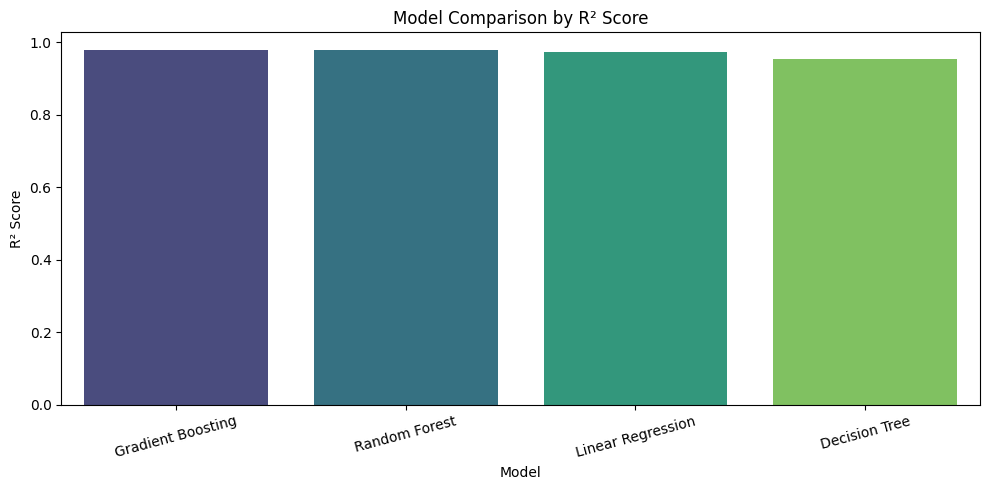

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Model Comparison by R² Score")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [24]:
from sklearn.model_selection import GridSearchCV

In [25]:
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0]
}

In [26]:
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)
print("Best Cross Validation R²:")
print(grid_search.best_score_)
best_model = grid_search.best_estimator_

pred_best = best_model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred_best))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred_best)))
print("R² :", r2_score(y_test, pred_best))

Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

In [ ]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Top 20 Most Important Features", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    pred_best,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Player Rating")
plt.ylabel("Predicted Player Rating")
plt.title("Actual vs Predicted Player Rating")

plt.tight_layout()
plt.show()

In [ ]:
residuals = y_test - pred_best

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pred_best,
    y=residuals,
    alpha=0.5
)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Player Rating")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(best_model, "../models/best_player_rating_model.pkl")

print("Model saved successfully!")